* ##  importing required Modules

In [1]:
import torch
import torchvision
from torchvision import datasets, transforms
import torch.nn as nn 
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import time 
import torchvision.models as models
import numpy as np
from torch.utils.data import random_split

In [3]:
device  = ("cuda" if torch.cuda.is_available() else "cpu")
device

'cpu'

* ## Data Loading and Visualization

In [6]:
#applies the transformation on the data. 

images_transformation = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2,contrast=0.2,saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],std=[0.229,0.224,0.225])              # imagenet values
])


In [8]:
dataset_path = "Downloads/course/deep learning/dataset"

dataset = datasets.ImageFolder(dataset_path,transform=images_transformation)

In [10]:
# classes in data
dataset.classes

['F_Breakage', 'F_Crushed', 'F_Normal', 'R_Breakage', 'R_Crushed', 'R_Normal']

In [12]:
num_classes = len(dataset.classes)
num_classes

6

In [14]:
# data splitting
train_size = int(0.75 * len(dataset))
val_size = len(dataset) - train_size
train_size,val_size

(1725, 575)

In [16]:
train_dataset,val_dataset = random_split(dataset,[train_size,val_size])


In [18]:
train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True)
val_loader =   DataLoader(val_dataset,batch_size=32,shuffle=True)

In [20]:
for images,labels in train_loader:
    print("images : ",images.shape)
    print("labels : ",labels.shape)
    break

images :  torch.Size([32, 3, 224, 224])
labels :  torch.Size([32])


### Images Visualization

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.6544228].


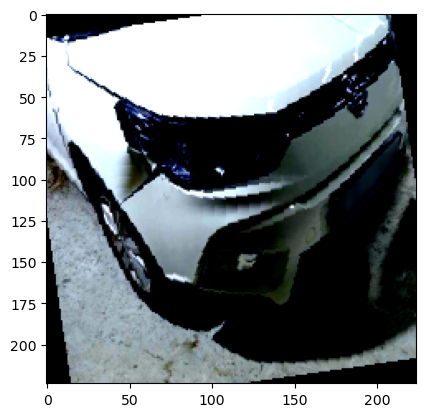

In [23]:
def show_images(img):
    img = img / 2 + 0.5 # unnormalize the images
    npimg = img.numpy()     # convert to numpy array
    plt.imshow(np.transpose(npimg,(1,2,0)))
    plt.show()

show_images(torchvision.utils.make_grid(images[3]))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.732854].


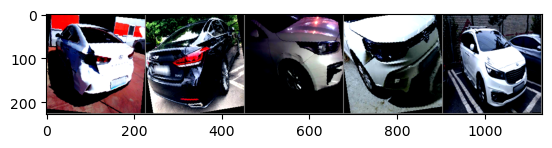

In [25]:
def show_images(img):
    img = img / 2 + 0.5 # unnormalize the images
    npimg = img.numpy()     # convert to numpy array
    plt.imshow(np.transpose(npimg,(1,2,0)))
    plt.show()

show_images(torchvision.utils.make_grid(images[:5]))

In [28]:
label = [dataset.classes[i] for i in labels]
label[0]

'R_Breakage'

In [30]:
label[:5]

['R_Breakage', 'R_Normal', 'F_Crushed', 'F_Crushed', 'F_Normal']

* ## Model 1: Training with CNN

In [33]:
class carclassifier(nn.Module):
    def __init__(self,num_classes):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv2d(in_channels=3,out_channels=16,kernel_size=(3,3),stride=1,padding=1),   # (16,224,224)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2,2),stride=(2,2),padding=0),                      # (16,112,112)
            nn.Conv2d(in_channels=16,out_channels=32,kernel_size=(3,3),stride=1,padding=1),   # (32,112,112)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2,2),stride=(2,2),padding=0),                       # (32,56,56)
            nn.Conv2d(in_channels=32,out_channels=64,kernel_size=(3,3),stride=1,padding=1),   # (64,56,56)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2,2),stride=(2,2),padding=0),                          # (64,28,28)
            nn.Flatten(),
            nn.Linear(64*28*28,512),
            nn.ReLU(),
            nn.Linear(512,num_classes)
        )
    def forward(self,x):
        x = self.network(x)
        return x
        

In [35]:
# instantiate the model, loss function, optimizer

model = carclassifier(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=0.001)

In [33]:
# create a function for training and validation

def model_training(model,optimizer,loss_function,epochs=5):
# model training
    start_time = time.time()
    
    for epoch in range(epochs):
        model.train()
        
        running_loss = 0
        
        for batch,(images,labels) in enumerate(train_loader):
            images,labels = images.to(device),labels.to(device)
            
            # forward pass
            optimizer.zero_grad()
            
            output = model(images)
            loss = criterion(output, labels)
            
            # backpropagation
            loss.backward()
            
            # weight updation
            optimizer.step()
            if (batch+1) % 10 == 0:
                print(f" batch {batch+1}, epoch {epoch+1}, loss : [ {loss.item():.4f} ]")
        
            running_loss += loss.item() * images.size(0) 
        avg_running_loss = running_loss / len(train_loader.dataset)
        print(f" epoch {epoch+1} / {epochs}, loss [{avg_running_loss}]")


# model evaluation
        model.eval()
        
        total = 0
        correct = 0
        all_labels = []
        all_predictions = []
        
        with torch.no_grad():
            for images,labels in val_loader:
                images,labels = images.to(device),labels.to(device)
                output = model(images)
                _,predicted = torch.max(output.data,1)
                
                correct += (predicted == labels).sum().item()
                total += labels.size(0)
                all_labels.extend(labels.numpy())
                all_predictions.extend(predicted.numpy())
            print(f" **** Validation Accuracy is: ,[ {100* correct / total:.2f} ] ****")


    end_time = time.time()
    print(f" Execution Time is : [ {end_time - start_time} ] seconds")
    
    return all_labels,all_predictions
                



In [108]:
all_labels,all_predictions = model_training(model,optimizer,criterion,epochs=10)

 batch 10, epoch 1, loss : [ 1.3719 ]
 batch 20, epoch 1, loss : [ 1.0168 ]
 batch 30, epoch 1, loss : [ 1.1893 ]
 batch 40, epoch 1, loss : [ 0.8543 ]
 batch 50, epoch 1, loss : [ 1.0119 ]
 epoch 1 / 10, loss [1.1025603904585908]
 **** Validation Accuracy is: ,[ 47.30 ] ****
 batch 10, epoch 2, loss : [ 0.9847 ]
 batch 20, epoch 2, loss : [ 1.0938 ]
 batch 30, epoch 2, loss : [ 0.8832 ]
 batch 40, epoch 2, loss : [ 0.9782 ]
 batch 50, epoch 2, loss : [ 1.1980 ]
 epoch 2 / 10, loss [1.0411756932217142]
 **** Validation Accuracy is: ,[ 49.39 ] ****
 batch 10, epoch 3, loss : [ 0.9802 ]
 batch 20, epoch 3, loss : [ 1.0131 ]
 batch 30, epoch 3, loss : [ 0.6653 ]
 batch 40, epoch 3, loss : [ 0.9582 ]
 batch 50, epoch 3, loss : [ 1.0706 ]
 epoch 3 / 10, loss [0.9975643849718397]
 **** Validation Accuracy is: ,[ 53.91 ] ****
 batch 10, epoch 4, loss : [ 0.8580 ]
 batch 20, epoch 4, loss : [ 1.1298 ]
 batch 30, epoch 4, loss : [ 0.8269 ]
 batch 40, epoch 4, loss : [ 0.8595 ]
 batch 50, epoch 

* ## Model 2: CNN Training With Regularization

In [115]:
class carclassifierwithRegularization(nn.Module):
    def __init__(self,num_classes):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv2d(in_channels=3,out_channels=16,kernel_size=(3,3),stride=1,padding=1),   # (16,224,224)
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2,2),stride=(2,2),padding=0),                      # (16,112,112)
            nn.Conv2d(in_channels=16,out_channels=32,kernel_size=(3,3),stride=1,padding=1),   # (32,112,112)
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2,2),stride=(2,2),padding=0),                       # (32,56,56)
            nn.Conv2d(in_channels=32,out_channels=64,kernel_size=(3,3),stride=1,padding=1),   # (64,56,56)
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2,2),stride=(2,2),padding=0),                          # (64,28,28)
            nn.Flatten(),
            nn.Linear(64*28*28,512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512,num_classes)
        )
    def forward(self,x):
        x = self.network(x)
        return x
        

In [117]:
# instantiate the model, loss function, optimizer

model = carclassifierwithRegularization(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=0.001,weight_decay=1e-4)


In [119]:
all_labels,all_predictions = model_training(model,optimizer,criterion,epochs=10)

 batch 10, epoch 1, loss : [ 8.4131 ]
 batch 20, epoch 1, loss : [ 5.6716 ]
 batch 30, epoch 1, loss : [ 1.9772 ]
 batch 40, epoch 1, loss : [ 1.5068 ]
 batch 50, epoch 1, loss : [ 1.4697 ]
 epoch 1 / 10, loss [7.003387091332588]
 **** Validation Accuracy is: ,[ 36.70 ] ****
 batch 10, epoch 2, loss : [ 1.5558 ]
 batch 20, epoch 2, loss : [ 1.3560 ]
 batch 30, epoch 2, loss : [ 1.4661 ]
 batch 40, epoch 2, loss : [ 1.5688 ]
 batch 50, epoch 2, loss : [ 1.4340 ]
 epoch 2 / 10, loss [1.428476485238559]
 **** Validation Accuracy is: ,[ 50.61 ] ****
 batch 10, epoch 3, loss : [ 1.4237 ]
 batch 20, epoch 3, loss : [ 1.3589 ]
 batch 30, epoch 3, loss : [ 1.1946 ]
 batch 40, epoch 3, loss : [ 1.1565 ]
 batch 50, epoch 3, loss : [ 1.3085 ]
 epoch 3 / 10, loss [1.2862947659561599]
 **** Validation Accuracy is: ,[ 51.13 ] ****
 batch 10, epoch 4, loss : [ 1.1160 ]
 batch 20, epoch 4, loss : [ 1.2335 ]
 batch 30, epoch 4, loss : [ 1.4221 ]
 batch 40, epoch 4, loss : [ 1.2076 ]
 batch 50, epoch 4,

* ## Model 3: Trainning with Transfer Learning -  EfficientNETb0

In [146]:
class CarClassifierEfficientNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.model = models.efficientnet_b0(weights='DEFAULT')
        
        for param in self.model.parameters():
            param.requires_grad = False
        
        in_features = self.model.classifier[1].in_features
        
        self.model.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_features, num_classes)
        )
        
    def forward(self, x):
        x = self.model(x)
        return x              

In [158]:
model = CarClassifierEfficientNet(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)



In [160]:
all_labels,all_predictions = model_training(model,optimizer,criterion,epochs=10)

 batch 10, epoch 1, loss : [ 1.6922 ]
 batch 20, epoch 1, loss : [ 1.5338 ]
 batch 30, epoch 1, loss : [ 1.3875 ]
 batch 40, epoch 1, loss : [ 1.3610 ]
 batch 50, epoch 1, loss : [ 1.2636 ]
 epoch 1 / 10, loss [1.5160684963585673]
 **** Validation Accuracy is: ,[ 56.00 ] ****
 batch 10, epoch 2, loss : [ 1.1585 ]
 batch 20, epoch 2, loss : [ 1.2838 ]
 batch 30, epoch 2, loss : [ 1.1487 ]
 batch 40, epoch 2, loss : [ 1.2101 ]
 batch 50, epoch 2, loss : [ 1.1279 ]
 epoch 2 / 10, loss [1.1879159270162167]
 **** Validation Accuracy is: ,[ 60.52 ] ****
 batch 10, epoch 3, loss : [ 1.0915 ]
 batch 20, epoch 3, loss : [ 1.0999 ]
 batch 30, epoch 3, loss : [ 1.1186 ]
 batch 40, epoch 3, loss : [ 1.0811 ]
 batch 50, epoch 3, loss : [ 1.0564 ]
 epoch 3 / 10, loss [1.0594197421143021]
 **** Validation Accuracy is: ,[ 64.87 ] ****
 batch 10, epoch 4, loss : [ 1.1563 ]
 batch 20, epoch 4, loss : [ 0.8603 ]
 batch 30, epoch 4, loss : [ 1.0655 ]
 batch 40, epoch 4, loss : [ 1.2793 ]
 batch 50, epoch 

* ## Model 4: Training with Transfer Learning - ResNet50 

In [35]:
# Load the pre-trained ResNet model
class CarClassifierResNet(nn.Module):
    def __init__(self, num_classes, dropout_rate=0.5):
        super().__init__()
        self.model = models.resnet50(weights='DEFAULT')
        # Freeze all layers except the final fully connected layer
        for param in self.model.parameters():
            param.requires_grad = False
            
        # Unfreeze layer4 and fc layers
        for param in self.model.layer4.parameters():
            param.requires_grad = True            
            
        # Replace the final fully connected layer
        self.model.fc = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(self.model.fc.in_features, num_classes)
        )

    def forward(self, x):
        x = self.model(x)
        return x

In [37]:
model = CarClassifierResNet(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)


In [47]:
all_labels,all_predictions = model_training(model,optimizer,criterion,epochs=10)

 batch 10, epoch 1, loss : [ 0.9358 ]
 batch 20, epoch 1, loss : [ 0.8965 ]
 batch 30, epoch 1, loss : [ 0.8773 ]
 batch 40, epoch 1, loss : [ 1.0910 ]
 batch 50, epoch 1, loss : [ 0.7715 ]
 epoch 1 / 10, loss [0.9003757177228513]
 **** Validation Accuracy is: ,[ 72.35 ] ****
 batch 10, epoch 2, loss : [ 0.4351 ]
 batch 20, epoch 2, loss : [ 0.5271 ]
 batch 30, epoch 2, loss : [ 0.4891 ]
 batch 40, epoch 2, loss : [ 0.6356 ]
 batch 50, epoch 2, loss : [ 0.7423 ]
 epoch 2 / 10, loss [0.5207088657738506]
 **** Validation Accuracy is: ,[ 72.70 ] ****
 batch 10, epoch 3, loss : [ 0.3842 ]
 batch 20, epoch 3, loss : [ 0.2659 ]
 batch 30, epoch 3, loss : [ 0.2595 ]
 batch 40, epoch 3, loss : [ 0.5041 ]
 batch 50, epoch 3, loss : [ 0.4910 ]
 epoch 3 / 10, loss [0.430250685767851]
 **** Validation Accuracy is: ,[ 78.78 ] ****
 batch 10, epoch 4, loss : [ 0.2497 ]
 batch 20, epoch 4, loss : [ 0.6156 ]
 batch 30, epoch 4, loss : [ 0.2346 ]
 batch 40, epoch 4, loss : [ 0.2207 ]
 batch 50, epoch 4

* ## Model 5: Training and Hyperparameter Tuning with Optuna

In [41]:
import optuna

In [48]:
def objective(trial):
    lr_rate = trial.suggest_float("lr",1e-5,1e-2,log=True)
    dropout_rate = trial.suggest_float("dropout_rate",0.2,0.7)
    
    # load the model
    model = CarClassifierResNet(num_classes=num_classes,dropout_rate=dropout_rate)
   
    # define criterion and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr_rate)

    # model training with hyperparameters
    epochs = 3
    start_time = time.time()
    for epoch in range(epochs):
        running_loss = 0
        for batch,(images,labels) in enumerate(train_loader):
            images,labels = images.to(device),labels.to(device)
            
            optimizer.zero_grad()
            output = model(images)
            loss = criterion(output,labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
        epoch_loss = running_loss / len(train_loader.dataset)
        
# validation
        model.eval()
        with torch.no_grad():
            
            correct = 0
            total = 0
            
            for images,labels in val_loader:
                output = model(images)
                images,labels = images.to(device),labels.to(device)
                _,predicted = torch.max(output.data,1)
                correct += (predicted == labels).sum().item()
                total += labels.size(0)
        accuracy = 100* correct / total
        
        # report the result with optuna
        trial.report(accuracy,epoch)
        
        if trial.should_prune():                              # if model performs badly stop early.
            raise optuna.exceptions.TrialPruned()

    end_time = time.time()
    
    print(f"The Total Execution Time is: {end_time - start_time} seconds")
    return accuracy


In [ ]:
study = optuna.create_study(direction="maximize")
study.optimize(objective,n_trials=20)

[I 2026-04-13 20:24:59,000] A new study created in memory with name: no-name-8137a509-b835-414a-a539-d9bc386862b4
[I 2026-04-13 20:36:50,376] Trial 0 finished with value: 66.95652173913044 and parameters: {'lr': 0.007259247494551021, 'dropout_rate': 0.4931423980960862}. Best is trial 0 with value: 66.95652173913044.


The Total Execution Time is: 710.9714744091034 seconds


[I 2026-04-13 20:48:29,553] Trial 1 finished with value: 67.65217391304348 and parameters: {'lr': 2.4396701399409143e-05, 'dropout_rate': 0.49017833709964226}. Best is trial 1 with value: 67.65217391304348.


The Total Execution Time is: 698.7611873149872 seconds


[I 2026-04-13 21:00:08,275] Trial 2 finished with value: 73.56521739130434 and parameters: {'lr': 0.0020111332354056616, 'dropout_rate': 0.6749218647350068}. Best is trial 2 with value: 73.56521739130434.


...

The Total Execution Time is: 716.7259576320648 seconds


[I 2026-04-13 22:11:58,997] Trial 12 pruned. 
[I 2026-04-13 22:24:27,583] Trial 13 finished with value: 74.08695652173913 and parameters: {'lr': 0.0007333708046839174, 'dropout_rate': 0.6147273847604168}. Best is trial 13 with value: 74.08695652173913.


The Total Execution Time is: 748.1327846050262 seconds


[I 2026-04-13 22:30:40,469] Trial 14 pruned. 
[I 2026-04-13 22:37:13,518] Trial 15 pruned. 
[I 2026-04-13 22:43:52,727] Trial 16 pruned. 
[I 2026-04-13 22:48:25,329] Trial 17 pruned. 
[I 2026-04-13 22:59:28,881] Trial 18 finished with value: 70.08695652173913 and parameters: {'lr': 0.0008985126100507208, 'dropout_rate': 0.40935608395589673}. Best is trial 13 with value: 74.08695652173913.


The Total Execution Time is: 663.1331551074982 seconds


#### With the HyperParameter Tuning the Model Gives Best Accuracy is: 74.0 with the Best Parameter For ResNet50 is 
#### parameters: {'lr': 0.0008985126100507208, 'dropout_rate': 0.4093560839558"

* ## Best Model with 80.52  % Accuracy: ResNet50 Model parameters is : { dropout_rate=0.5 and lr=0.001 }
* ### We Have Select the Highest Accuracy Model is : Model 4

In [47]:
# Load the pre-trained ResNet model
class CarClassifierResNet(nn.Module):
    def __init__(self, num_classes, dropout_rate=0.5):
        super().__init__()
        self.model = models.resnet50(weights='DEFAULT')
        # Freeze all layers except the final fully connected layer
        for param in self.model.parameters():
            param.requires_grad = False
            
        # Unfreeze layer4 and fc layers
        for param in self.model.layer4.parameters():
            param.requires_grad = True            
            
        # Replace the final fully connected layer
        self.model.fc = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(self.model.fc.in_features, num_classes)
        )

    def forward(self, x):
        x = self.model(x)
        return x

In [49]:
model = CarClassifierResNet(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)


In [51]:
all_labels,all_predictions = model_training(model,optimizer,criterion,epochs=10)

 batch 10, epoch 1, loss : [ 1.0105 ]
 batch 20, epoch 1, loss : [ 0.7124 ]
 batch 30, epoch 1, loss : [ 0.5945 ]
 batch 40, epoch 1, loss : [ 0.6109 ]
 batch 50, epoch 1, loss : [ 0.8426 ]
 epoch 1 / 10, loss [0.8844865269246309]
 **** Validation Accuracy is: ,[ 69.22 ] ****
 batch 10, epoch 2, loss : [ 0.9555 ]
 batch 20, epoch 2, loss : [ 0.5314 ]
 batch 30, epoch 2, loss : [ 0.5426 ]
 batch 40, epoch 2, loss : [ 0.4229 ]
 batch 50, epoch 2, loss : [ 0.6517 ]
 epoch 2 / 10, loss [0.551820868132771]
 **** Validation Accuracy is: ,[ 74.78 ] ****
 batch 10, epoch 3, loss : [ 0.4103 ]
 batch 20, epoch 3, loss : [ 0.4579 ]
 batch 30, epoch 3, loss : [ 0.5439 ]
 batch 40, epoch 3, loss : [ 0.3431 ]
 batch 50, epoch 3, loss : [ 0.2624 ]
 epoch 3 / 10, loss [0.41850928221923717]
 **** Validation Accuracy is: ,[ 76.00 ] ****
 batch 10, epoch 4, loss : [ 0.1835 ]
 batch 20, epoch 4, loss : [ 0.2773 ]
 batch 30, epoch 4, loss : [ 0.5071 ]
 batch 40, epoch 4, loss : [ 0.2065 ]
 batch 50, epoch 

* ## Classification Report

In [58]:
from sklearn.metrics import classification_report

report = classification_report(all_labels,all_predictions)
print(report)

              precision    recall  f1-score   support

           0       0.84      0.84      0.84       116
           1       0.72      0.80      0.76       106
           2       0.91      0.84      0.87       148
           3       0.80      0.79      0.80        67
           4       0.74      0.76      0.75        75
           5       0.77      0.73      0.75        63

    accuracy                           0.81       575
   macro avg       0.80      0.79      0.79       575
weighted avg       0.81      0.81      0.81       575



* ## Confusion Matrix

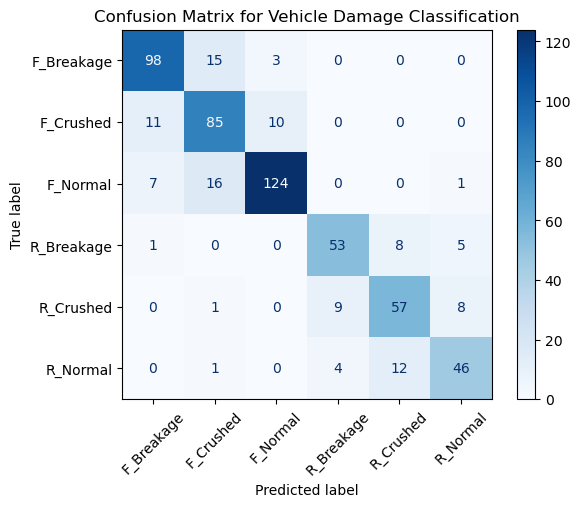

In [64]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

class_names = dataset.classes
conf_matrix = confusion_matrix(all_labels, all_predictions, labels=np.arange(num_classes))
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix for Vehicle Damage Classification")
plt.show()

* ## Model Saving

In [72]:
torch.save(model.state_dict(),"best_model.pt")